In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks


In [61]:
import pandas as pd


# sipin_path = r"C:\Users\maryl\Documents\Universite\Session_6\tp_biom\exam_lab\Si-PIN_60.30x_Am241_60s_1024.mca"
sipin_path = r"C:\Users\charl\OneDrive\UL\Travaux pratiques PhysMed\Filtration X\TPmedical\spectres_bruts\filtration\MiniX_76.70X_4096_40kV_90uA.mca"

with open(sipin_path, "r") as f:
    lines = f.readlines()

# Exemple : garder seulement les lignes numériques
data = []
for line in lines:
    try:
        value = float(line.strip())
        data.append(value)
    except:
        pass


df = pd.DataFrame(data, columns=["Counts"])
df.to_csv(r"C:\Users\charl\OneDrive\UL\Travaux pratiques PhysMed\Filtration X\TPmedical\csv\sec_efficace\no_filter_90.csv", index=False)

[ 0.  0.  0. ... 16. 27. 32.]


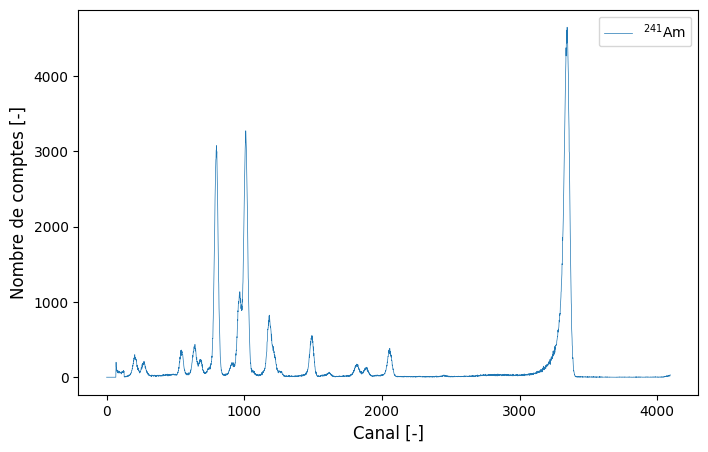

In [13]:
df = pd.read_csv('csv\Am241_76.70X_4096_etalonnage1.csv')
Am241 = df.to_numpy().ravel()
print(Am241)


fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Am241, lw=0.5, label=r"$^{241}$Am")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

[ 796  798 1009 1011 3338 3343 3346 3348]


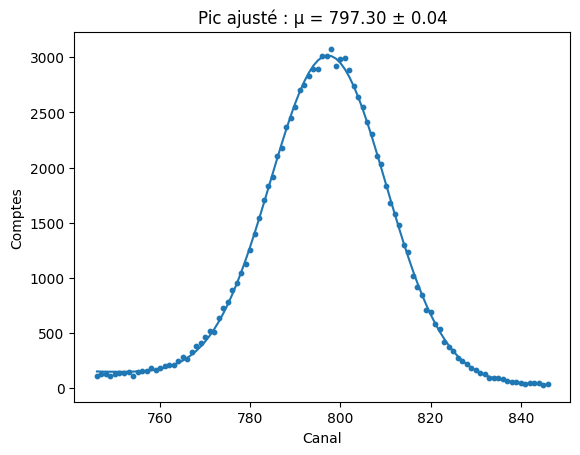

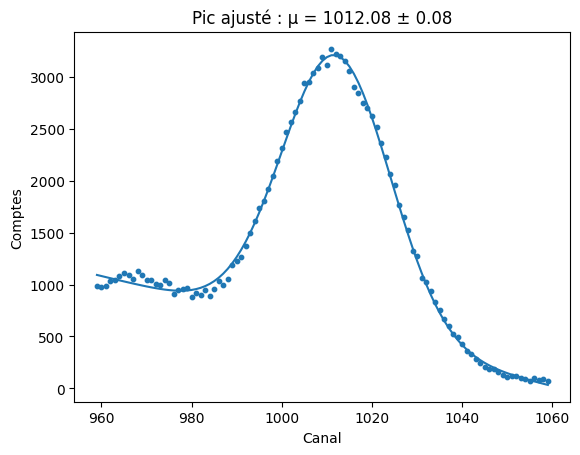

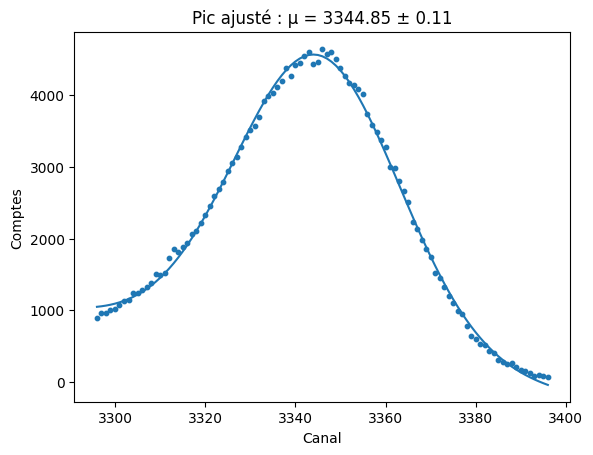

In [14]:
# Modèle gaussienne + fond linéaire
def gaussian_with_background(x, A, mu, sigma, m, c):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + m*x + c


def fit_peak(counts, peak_center, window=30, plot=True):
    """
    counts : array numpy des comptes
    peak_center : estimation approximative du pic
    window : nombre de canaux autour du pic
    """

    # Définition de la région de fit
    x_min = peak_center - window
    x_max = peak_center + window
    
    x = np.arange(len(counts))
    mask = (x >= x_min) & (x <= x_max)

    x_fit = x[mask]
    y_fit = counts[mask]

    # Valeurs initiales
    A0 = max(y_fit)
    mu0 = peak_center
    sigma0 = window/3
    m0 = 0
    c0 = min(y_fit)

    p0 = [A0, mu0, sigma0, m0, c0]

    # Fit
    popt, pcov = curve_fit(gaussian_with_background, x_fit, y_fit, p0=p0)

    A, mu, sigma, m, c = popt
    mu_err = np.sqrt(np.diag(pcov))[1]
    sigma_err = np.sqrt(np.diag(pcov))[2]

    # Nombre de compte dans le pic
    N_pic = A*sigma*np.sqrt(2*np.pi)


    if plot:
        plt.figure()
        plt.scatter(x_fit, y_fit, s=10)
        plt.plot(x_fit, gaussian_with_background(x_fit, *popt))
        plt.title(f"Pic ajusté : μ = {mu:.2f} ± {mu_err:.2f}")
        plt.xlabel("Canal")
        plt.ylabel("Comptes")
        plt.show()

    return mu, mu_err, sigma, sigma_err, N_pic


peaks, _ = find_peaks(Am241, height=3000)  # ajuster height
print(peaks)

mu_Am1, mu_err_Am1, sigma_Am1, sigma_err_Am1, _ = fit_peak(Am241, peak_center=796, window=50)

mu_Am2, mu_err_CAm2, sigma_Am2, sigma_err_Am2, _ = fit_peak(Am241, peak_center=1009, window=50)

mu_Am3, mu_err_Am3, sigma_Am3, sigma_err_Am3, _ = fit_peak(Am241, peak_center=3346, window=50)


# Étalonnage

Gain (keV/canal) = 0.017905141963904726
Offset (keV) = -0.35239275479242


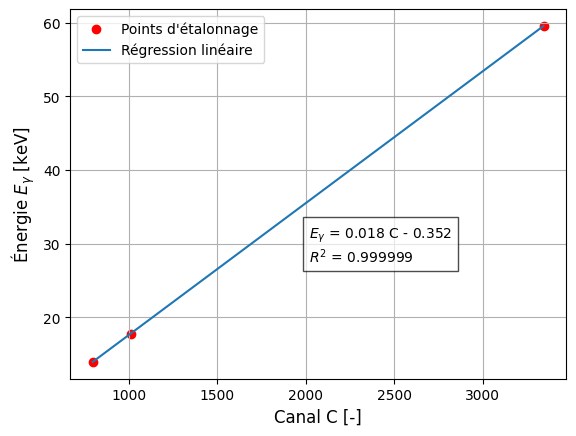

In [17]:
# Étalonnage

channels = np.array([mu_Am1, mu_Am2, mu_Am3])
energies = np.array([13.95, 17.74, 59.54])


coeff = np.polyfit(channels, energies, 1)

a = coeff[0]
b = coeff[1]

print("Gain (keV/canal) =", a)
print("Offset (keV) =", b)  


def etalon(channel):
    return a * channel + b

# Calcul de R^2
ss_res = np.sum((energies - etalon(channels))**2)
ss_tot = np.sum((energies - np.mean(energies))**2)
r2 = 1 - ss_res/ss_tot


plt.scatter(channels, energies, label="Points d'étalonnage", color='red')
plt.plot(channels, etalon(channels), label="Régression linéaire")


# Calcul du point milieu
x_mid = np.mean(channels)
y_mid = a * x_mid + b

# Affichage équation sur le graphe
plt.text(x_mid+300,
         y_mid-3,
         r"$E_\gamma$"+f" = {a:.3f} C - {np.abs(b):.3f}\n$R^2$ = {r2:.6f}",
         fontsize=10,
         bbox=dict(facecolor='white', alpha=0.7))

plt.xlabel("Canal C [-]", size=12)
plt.ylabel(r"Énergie $E_\gamma$ [keV]", size=12)
plt.legend(loc="best")
plt.grid()


plt.show()

# Section efficace

In [62]:
df = pd.read_csv(r'csv\sec_efficace\Ag_1mils.csv')
Ag_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\Al_10mils.csv')
Al_10mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\Cu_2mils.csv')
Cu_2mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\Mo_1mils.csv')
Mo_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\W_1mils.csv')
W_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\no_filter.csv')
no_filter = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\no_filter_90.csv')
no_filter_90 = df.to_numpy().ravel()


3473.0
[  94.76666667   58.00833333 1337.96666667  879.33333333 1059.56666667]
[2.35285179e-21 9.51572608e-21 5.86622199e-21 9.22468939e-21
 7.39293749e-21]


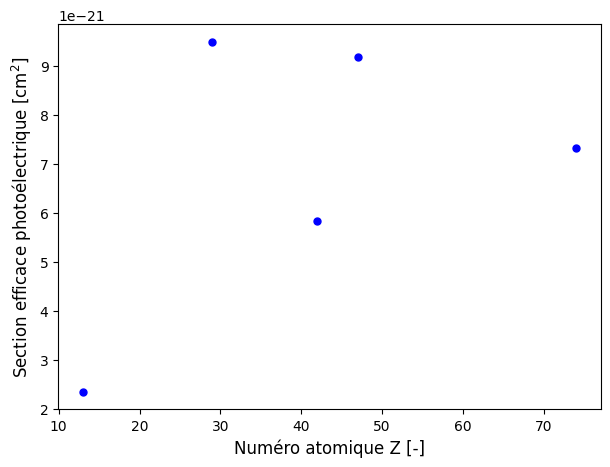

' # CALCUL R²\nFWHM_fit = fwhm_model2(E, a_fit, b_fit)\n#FWHM_fit = fwhm_model2(E, a_fit)\n\nss_res = np.sum((FWHM - FWHM_fit) ** 2)\nss_tot = np.sum((FWHM - np.mean(FWHM)) ** 2)\nR2_fwhm = 1 - ss_res / ss_tot\n\n\nRrel_fit = Rrel_model2(E, c_fit, d_fit)\n\nss_res = np.sum((R - Rrel_fit) ** 2)\nss_tot = np.sum((R - np.mean(R)) ** 2)\nR2_Rrel = 1 - ss_res / ss_tot\n\n\n#print(E)\n#print(E_err)\n\nprint(a_fit, b_fit)\nprint(c_fit, d_fit)\n\nprint(R2_fwhm)\nprint(R2_Rrel)\n'

In [65]:
NA = 6.022e23
mils = 25.4e-4

def sec_eff(N0, Nt, rho, t, A):
    return (-np.log(Nt/N0) * A) / (rho * t * NA) - 0.20 * (A / NA)


# NIST, NIH
A = np.array([26.9815385, 63.546, 95.95, 107.8682, 183.84])
rho = np.array([2.70, 8.933, 10.2, 10.501, 19.3])
t = np.array([10, 2, 1, 1, 1]) * mils


N0 = np.sum(no_filter_90[1700:1900]) / 30
Nt_Ag = np.sum(Ag_1mils[1700:1900]) / 30
Nt_Al = np.sum(Al_10mils[1700:1900]) / 90
Nt_Cu = np.sum(Cu_2mils[1700:1900]) / 120
Nt_Mo = np.sum(Mo_1mils[1700:1900]) / 30
Nt_W = np.sum(W_1mils[1700:1900]) / 30
Nt = np.array([Nt_Al, Nt_Cu, Nt_Mo, Nt_Ag, Nt_W])
print(N0)
print(Nt)
print((-np.log(Nt/N0))/(rho*t) * (A/NA))



sec_efficace= sec_eff(N0, Nt, rho, t, A)
Z = [13, 29, 42, 47, 74]
     

def model(Z, c, n):
    return c * Z**n

popt_model, _ = curve_fit(model, Z, sec_efficace)
c_fit, n_fit = popt_model


# =============================
# TRACE UNIQUE GRAPHIQUE
# =============================

fig, ax1 = plt.subplots(figsize=(7,5))
Z_fit = np.linspace(min(Z), max(Z), 300)


# FWHM
ax1.errorbar(Z, sec_efficace, fmt='o', ms=5, color="blue")#, label="Données résolution absolue")
#ax1.plot(E_fit, fwhm_model2(E_fit, a_fit, b_fit), color="blue", label=r"Fit: $R_{abs} = 2.45\sqrt{E}-10.10$"+"\n"+r"$\quad\quad R^2=0.99169$")
ax1.set_xlabel("Numéro atomique Z [-]", size=12)
ax1.set_ylabel(r"Section efficace photoélectrique [cm$^2$]", size=12)
#ax1.legend(loc=(0.2,0.77))

plt.show()

#yerr=FWHM_err


""" # CALCUL R²
FWHM_fit = fwhm_model2(E, a_fit, b_fit)
#FWHM_fit = fwhm_model2(E, a_fit)

ss_res = np.sum((FWHM - FWHM_fit) ** 2)
ss_tot = np.sum((FWHM - np.mean(FWHM)) ** 2)
R2_fwhm = 1 - ss_res / ss_tot


Rrel_fit = Rrel_model2(E, c_fit, d_fit)

ss_res = np.sum((R - Rrel_fit) ** 2)
ss_tot = np.sum((R - np.mean(R)) ** 2)
R2_Rrel = 1 - ss_res / ss_tot


#print(E)
#print(E_err)

print(a_fit, b_fit)
print(c_fit, d_fit)

print(R2_fwhm)
print(R2_Rrel)
"""

26.50532019106467
35.45789117301703


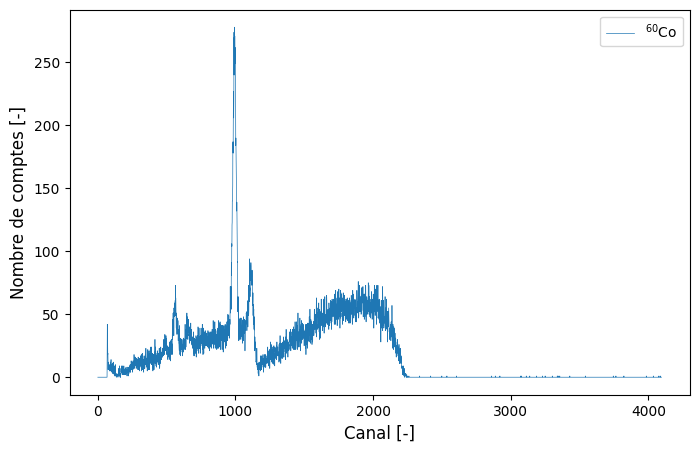

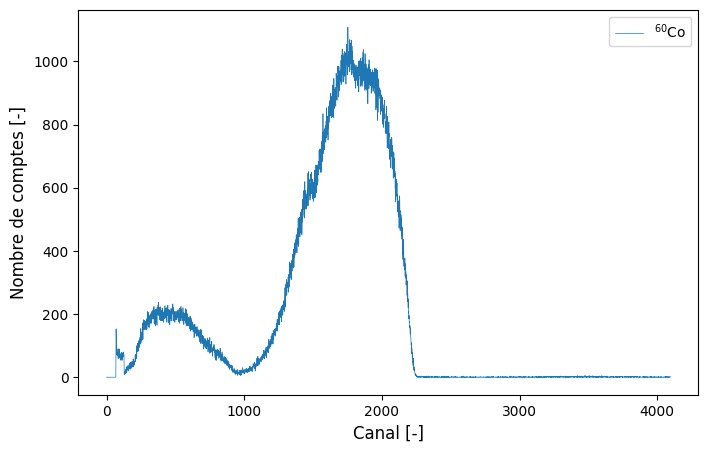

In [58]:
df = pd.read_csv(r'csv\sec_efficace\Mo_V2.csv')
Mo = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\W_V2.csv')
W = df.to_numpy().ravel()



print(etalon(1500))
print(etalon(2000))

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Mo, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), W, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()



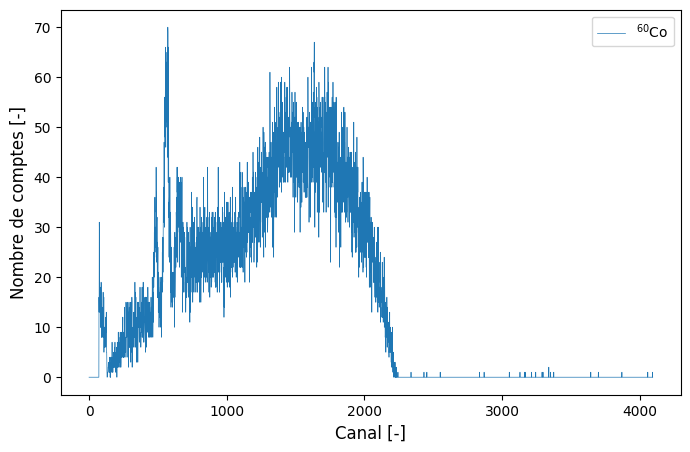

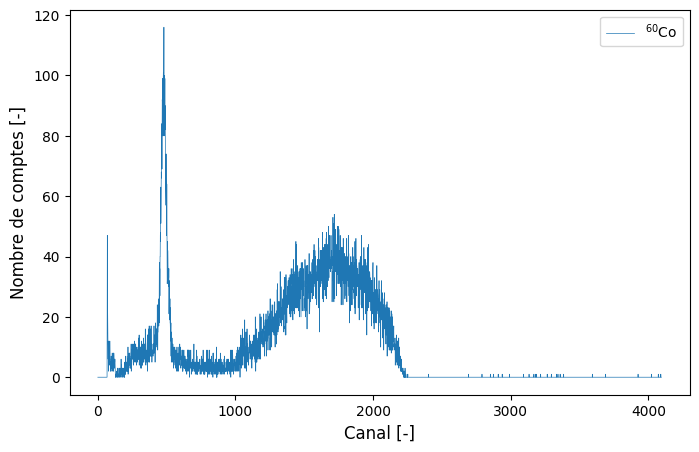

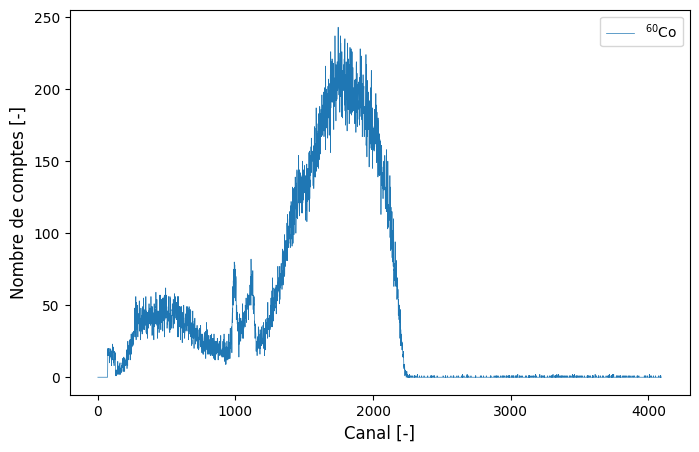

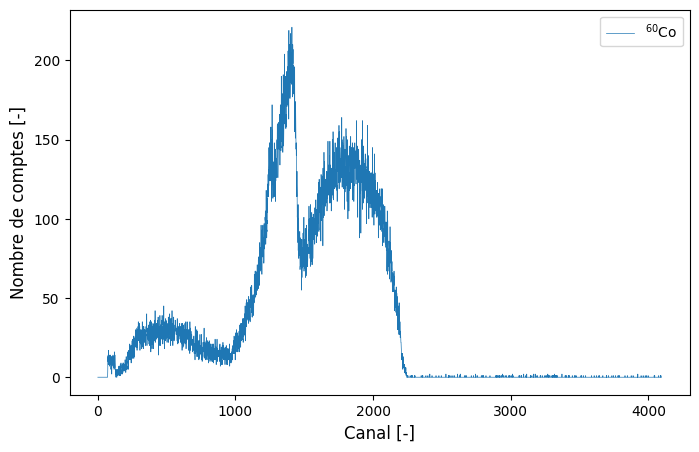

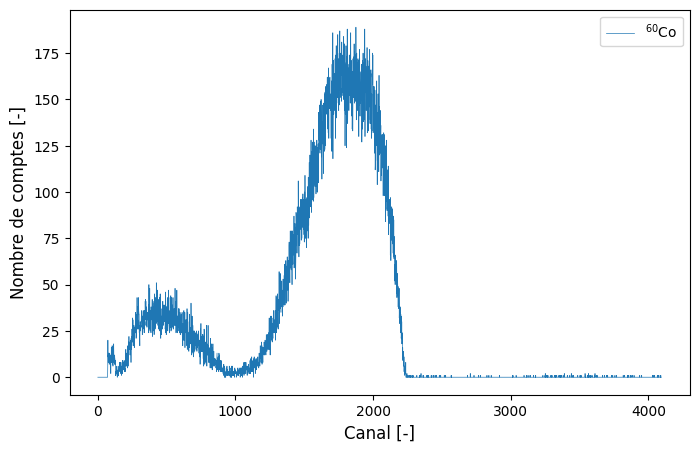

In [38]:

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Al_10mils, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Cu_2mils, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Mo_1mils, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Ag_1mils, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), W_1mils, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()